# Task 5 — A real time series
Dataset: `flights.csv`, monthly airline passengers in thousands, 1949-1960, 144 rows. Small and clean, so the hard part here is the chart design, not the data cleaning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("data")
CHARTS = Path("charts")
CHARTS.mkdir(exist_ok=True)

# ---- House palette (colour-blind safe, same as the lecture notebook) ----
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
YELLOW, MAGENTA = "#eda100", "#e87ba4"
GREEN, VIOLET, RED = "#008300", "#4a3aa7", "#e34948"
SERIES = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED]
INK, INK_SOFT, INK_MUTED = "#0b0b0b", "#52514e", "#8a8985"
GRID, SURFACE, QUIET = "#e6e5e1", "#fcfcfb", "#cfceca"

plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_SOFT, "axes.titlecolor": INK,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 14, "axes.labelsize": 10, "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT, "legend.frameon": False,
    "legend.fontsize": 10, "lines.linewidth": 2, "font.size": 11,
    "savefig.dpi": 150, "savefig.bbox": "tight",
})

def save(fig, name):
    fig.savefig(CHARTS / f"{name}.png", facecolor=SURFACE)

def note(ax, text, y=-0.2):
    """Footnote under a chart - used to say what was excluded."""
    ax.text(0, y, text, transform=ax.transAxes, fontsize=9, color=INK_MUTED)

## 1. Getting one ordered time axis
`year` and `month` come as separate columns and `month` is a text name. Sorting that alphabetically would put April before January, so step one is combining them into an actual date column — this is really the whole task, the plotting after is easy.

In [2]:
f = pd.read_csv(DATA / "flights.csv")
f["date"] = pd.to_datetime(f["year"].astype(str) + "-" + f["month"], format="%Y-%B")
f = f.sort_values("date").reset_index(drop=True)
f["month_num"] = f["date"].dt.month
print(f.shape, "| missing:", int(f.isna().sum().sum()), "|", f.date.min().date(), "->", f.date.max().date())
f.head()

(144, 5) | missing: 0 | 1949-01-01 -> 1960-12-01


,year,month,passengers,date,month_num
0,1949,January,112,1949-01-01,1
1,1949,February,118,1949-02-01,2
2,1949,March,132,1949-03-01,3
3,1949,April,129,1949-04-01,4
4,1949,May,121,1949-05-01,5


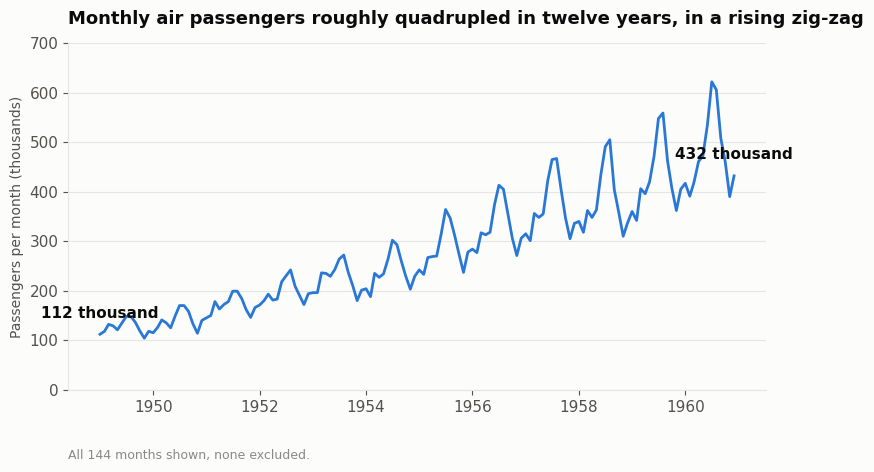

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(f.date, f.passengers, color=BLUE, zorder=3)
ax.set_ylim(0, 700)
first, last = f.iloc[0], f.iloc[-1]
for r in (first, last):
    ax.annotate(f"{r.passengers} thousand", (r.date, r.passengers), textcoords="offset points",
                xytext=(0, 12), ha="center", fontsize=11, fontweight="bold", color=INK)
ax.set_title("Monthly air passengers roughly quadrupled in twelve years, in a rising zig-zag")
ax.title.set_fontsize(12)
ax.set_ylabel("Passengers per month (thousands)")
ax.xaxis.grid(False)
note(ax, "All 144 months shown, none excluded.")
save(fig, "t5_1_line")
plt.show()

Line chart because the x-axis is time, evenly spaced, and I'm tracking how one number changes across it — the line is basically saying "read these points in order".

What's visible is two things tangled together: a long climb (112 thousand in Jan 1949 up to 432 thousand by Dec 1960, with the single busiest month, July 1960, hitting 622 thousand) and a jagged up-down cycle riding on top of it every year. Both patterns are in there but you can't really separate them by eye from this chart alone — that's what the next two are for.

## 2. Isolate the seasonal cycle
One line per year, months on the x-axis. Year is an *ordered* variable, so I use a light-to-dark blue gradient (darker = later); colour has a meaning.

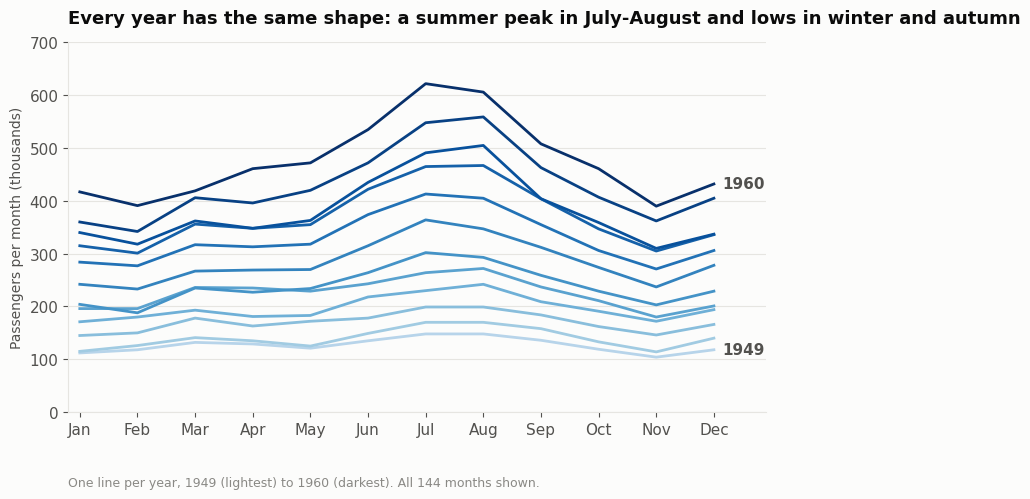

In [4]:
import matplotlib as mpl
years = sorted(f.year.unique())
cmap = mpl.colormaps["Blues"]
mnames = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(9, 4.8))
for i, y in enumerate(years):
    d = f[f.year == y]
    ax.plot(d.month_num, d.passengers, color=cmap(0.3 + 0.7 * i / (len(years) - 1)), linewidth=2, zorder=3)
for y in (1949, 1960):
    d = f[f.year == y]
    ax.text(12.15, d.passengers.iloc[-1], str(y), va="center", fontweight="bold", color=INK_SOFT)
ax.set_xticks(range(1, 13)); ax.set_xticklabels(mnames)
ax.set_xlim(0.8, 12.9); ax.set_ylim(0, 700)
ax.set_title("Every year has the same shape: a summer peak in July-August and lows in winter and autumn")
ax.title.set_fontsize(12)
ax.set_ylabel("Passengers per month (thousands)")
ax.xaxis.grid(False)
note(ax, "One line per year, 1949 (lightest) to 1960 (darkest). All 144 months shown.")
save(fig, "t5_2_seasonal")
plt.show()

**Why one line per year over a shared 12-month axis:** stacking the years on top of each other removes time as a driver and leaves only the within-year pattern. The lines are nearly parallel curves: up from February, peaking July-August, and falling to a low in November. The lines get higher each year (the trend) but their *shape* repeats.

## 3. Which month is consistently busiest?
To make this obvious at a glance I need to remove the growth trend, otherwise later years dominate any average. So each month's passengers are divided by *that year's* monthly average (100 = an average month of that year), then averaged over the 12 years. Bars start at zero; the reference line marks 100.

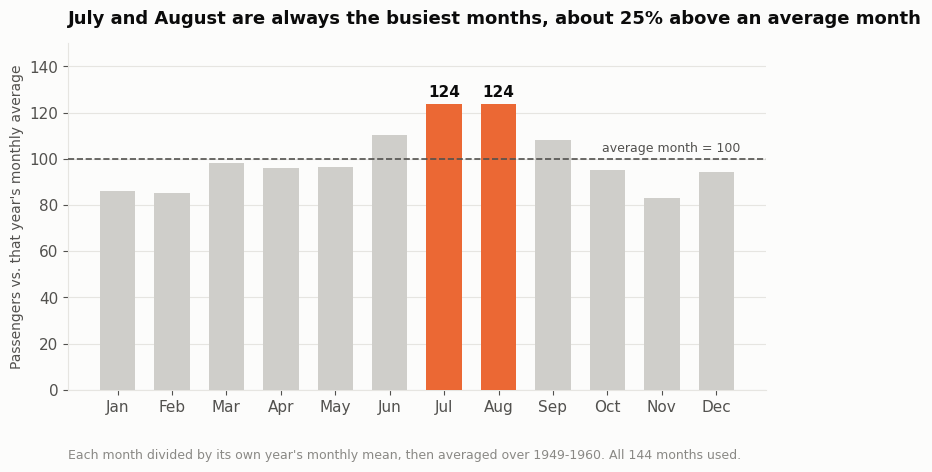

Years in which each month was the peak: {7: 7, 8: 5}
{1: 86.0, 2: 85.0, 3: 98.0, 4: 96.0, 5: 97.0, 6: 110.0, 7: 124.0, 8: 124.0, 9: 108.0, 10: 95.0, 11: 83.0, 12: 94.0}


In [5]:
f["index"] = f.passengers / f.groupby("year").passengers.transform("mean") * 100
idx = f.groupby("month_num")["index"].mean()
peak_counts = f.loc[f.groupby("year").passengers.idxmax()].month_num.value_counts()

fig, ax = plt.subplots(figsize=(9, 4.5))
colours = [ORANGE if m in (7, 8) else QUIET for m in idx.index]
bars = ax.bar(mnames, idx.values, color=colours, width=0.65, zorder=3)
ax.axhline(100, color=INK_SOFT, linewidth=1.2, linestyle="--", zorder=4)
ax.text(11.45, 103, "average month = 100", ha="right", fontsize=9, color=INK_SOFT)
for i in (6, 7):
    ax.text(i, idx.values[i] + 3, f"{idx.values[i]:.0f}", ha="center", fontweight="bold", color=INK)
ax.set_ylim(0, 150)
ax.set_title("July and August are always the busiest months, about 25% above an average month")
ax.title.set_fontsize(12)
ax.set_ylabel("Passengers vs. that year's monthly average")
ax.xaxis.grid(False); ax.set_axisbelow(True)
note(ax, "Each month divided by its own year's monthly mean, then averaged over 1949-1960. All 144 months used.")
save(fig, "t5_3_busiest_month")
plt.show()
print("Years in which each month was the peak:", peak_counts.to_dict())
print(idx.round(0).to_dict())

Bar chart with two bars picked out in colour — this is a comparison across 12 separate, unordered categories, so bars against a common baseline are the right tool, and leaving everything grey except July/August makes the finding obvious without needing to read the axis. Detrending first (dividing by that year's own average) matters here, otherwise the answer would just be whichever month happened to fall in a high-growth year.

July or August wins every single year — July 7 times, August 5 times out of 12 — so strictly there are two peak months, with July a bit ahead.

## 4. Which chart goes in a report?
**Put in the report: Chart 3 (busiest month)** — if the report is about planning or capacity, it gives one clear, decision-ready message ("expect ~25% more traffic in July-August") with the growth trend already removed.

If the report must show *growth*, **Chart 1** is the alternative, but it should then be stated as the growth chart and not as the seasonal chart.

**Why the other two do not belong together with it:**
- **Chart 1** tries to carry two messages at once (trend *and* season). The reader sees a jagged line but has to decide which part is which. It is a good exploration chart, but it has no single message.
- **Chart 2** has 12 overlapping lines. It is the best chart for *proving* the seasonal shape is stable, but it is dense and its message is the same as Chart 3's, only harder to read. Chart 3 says it in two seconds.

So: one chart, one message: Chart 3, with Chart 1 only if growth is the report's topic.

## Is the seasonal swing itself growing, or is the airline just getting bigger?
The raw swing definitely grows — peak minus trough goes from 44 thousand in 1949 to 232 thousand in 1960. But that's exactly what you'd expect if the airline just got about 4x bigger and the seasonal shape stayed the same the whole time.

To actually settle it, plot each year's monthly values as a percentage of that year's own average — same index as chart 3, but kept as one line per year instead of averaged together. If seasonality is purely growth-scaled, all 12 lines should sit on top of each other. If the seasonal swing is itself getting bigger, later years should visibly swing wider than earlier ones.

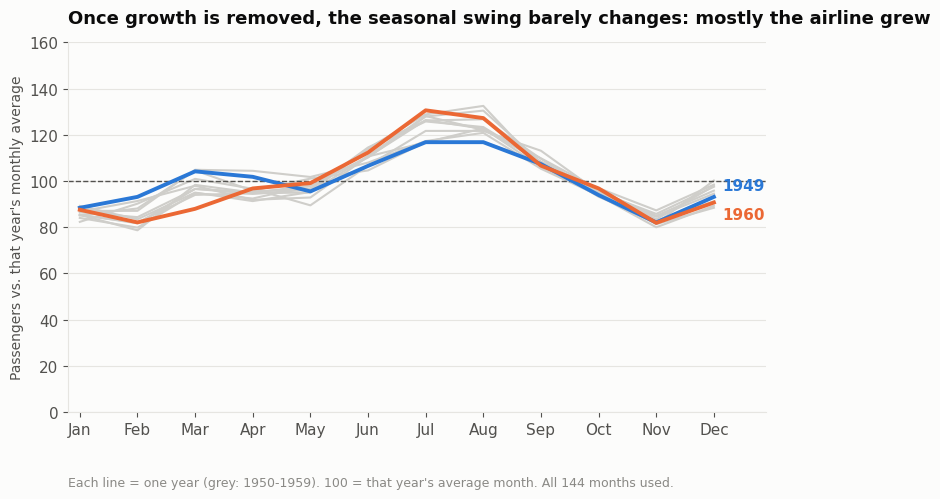

,min,max,peak_to_trough_thousands,peak_over_trough
year,,,,
1949,104,148,44,1.42
1950,114,170,56,1.49
1951,145,199,54,1.37
1952,171,242,71,1.42
1953,180,272,92,1.51
1954,188,302,114,1.61
1955,233,364,131,1.56
1956,271,413,142,1.52
1957,301,467,166,1.55


In [6]:
fig, ax = plt.subplots(figsize=(9, 4.8))
for y in years:
    d = f[f.year == y]
    if y in (1949, 1960):
        continue
    ax.plot(d.month_num, d["index"], color=QUIET, linewidth=1.5, zorder=2)
for y, colour in ((1949, BLUE), (1960, ORANGE)):
    d = f[f.year == y]
    ax.plot(d.month_num, d["index"], color=colour, linewidth=2.8, zorder=4)
    off = 5 if y == 1949 else -5
    ax.text(12.15, d["index"].iloc[-1] + off, str(y), color=colour, va="center", fontweight="bold")
ax.axhline(100, color=INK_SOFT, linewidth=1, linestyle="--")
ax.set_xticks(range(1, 13)); ax.set_xticklabels(mnames)
ax.set_xlim(0.8, 12.9); ax.set_ylim(0, 160)
ax.set_title("Once growth is removed, the seasonal swing barely changes: mostly the airline grew")
ax.title.set_fontsize(12)
ax.set_ylabel("Passengers vs. that year's monthly average")
ax.xaxis.grid(False)
note(ax, "Each line = one year (grey: 1950-1959). 100 = that year's average month. All 144 months used.")
save(fig, "t5_4_seasonality_settled")
plt.show()

s = f.groupby("year").passengers.agg(["min", "max"])
s["peak_to_trough_thousands"] = s["max"] - s["min"]
s["peak_over_trough"] = (s["max"] / s["min"]).round(2)
s

Looks like it's mostly the airline growing. The raw swing in thousands rose more than fivefold (44 to 232), but the peak-to-trough ratio only moved from about 1.4 to about 1.6, and the yearly lines on the index chart sit almost on top of each other. So there's at most a mild real increase in the relative seasonal swing — the 1960 line is a touch wider than 1949's — but most of what looked like growing seasonality in chart 1 is really just the whole series scaling up.

(Same conclusion comes out if you instead plot the original series on a log y-axis, where equal percentage swings end up looking equally tall — the swings come out looking roughly constant there too.)